# Group 2, Notebook_C (Student C): reliability, sensitivity, and practical limits

**Notebook_C covers Steps 6b and 6c, and answers RQ3.**

> **RQ3:** Are Notebook_B's results **robust**, or do they only hold for one particular split, one threshold, one declustering method?

Notebook_B answers "does the model beat the baselines". Notebook_C asks the harder question: **does that result hold when we change each assumption one at a time?** Seven checks, each one hitting one assumption:

| # | What changes | If the result collapses, it means |
|---|---|---|
| 1 | bootstrap confidence interval | the AUC figure is less precise than it looks |
| 2 | label threshold → **damaging** level | the work only holds at a threshold set by the data |
| 3 | mainshock threshold (5.0 / 5.5 / 6.0) | the result depends on an arbitrary choice |
| 4 | **drop 2011 entirely** | Tohoku is carrying the whole signal |
| 5 | split by **geographic region** instead of time | the model does not generalize to unseen regions |
| 6 | change declustering parameters | the conclusion is an artifact of Gardner-Knopoff, not of nature |
| 7 | **drop events with a default depth** (10/33/35 km) | the depth signal is an artifact of filled-in values, not of measured depth |

Checks 2 and 4 are the most important, because they hit practical relevance directly.

## Asking AI as you go and keeping an Audit Log: a light, tidy workflow

Record it in `docs/AI_Audit_Log_C.md`.

A rule specific to Notebook_C: **bad results must be reported too.** The job of this notebook is to find where the work is weak. If a check makes the result collapse and the group hides it, the whole work loses its value. One clearly reported failed check is **worth more** than five hand-picked successful ones.

## Step 0: check both handoffs

In [1]:
# Step 0: receive the handoffs from A and B
import json, hashlib, pathlib, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path("."); PROC = ROOT/"data"/"processed"; REP = ROOT/"report"
man  = json.load(open(PROC/"manifest.json", encoding="utf-8"))
rq2  = json.load(open(PROC/"rq2_summary.json", encoding="utf-8"))
ms   = pd.read_parquet(PROC/"mainshocks.parquet")
cat  = pd.read_parquet(PROC/"catalog_declustered.parquet")

assert hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16] == man["sha256_mainshocks"]
print("Handoff A: OK");  print("Handoff B: OK")
print(f"\nNotebook_B results to re-check:")
print(f"  main model              : {rq2['best_model']}  on {rq2['features']}")
print(f"  test AUC                : {rq2['auc_test']:.4f}  (gap {rq2['gap']:+.4f})")
print(f"  classic Omori baseline  : {rq2['omori_auc']:.4f}")
print(f"  extended Omori baseline : {rq2['omori_extended_auc']:.4f}")
print(f"  gain from depth         : {rq2['gain_from_depth']:+.4f}")
print(f"  gain from model type    : {rq2['gain_from_model_type']:+.4f}")

Handoff A: OK
Handoff B: OK

Notebook_B results to re-check:
  main model              : Random Forest (mag+depth)  on ['mag', 'depth']
  test AUC                : 0.8455  (gap +0.0353)
  classic Omori baseline  : 0.5971
  extended Omori baseline : 0.8402
  gain from depth         : +0.2431
  gain from model type    : +0.0053


In [2]:
# Shared style
PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,"axes.edgecolor":PAL["axis"],
    "axes.labelcolor":PAL["ink2"],"axes.grid":True,"grid.color":PAL["grid"],
    "grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})
def finish(ax,title,sub=None,xlab=None,ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax
def save(fig,name):
    fig.savefig(REP/name); print("saved figure:", REP/name)
print("style ready")

style ready


## Step 4 (repeated to stay independent of B): the same split, and shared functions

Notebook_C rebuilds B's split from scratch instead of taking it as given, so that if B has a bug, C catches it.

In [3]:
# Step 4: rebuild the split + shared functions
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import roc_auc_score, average_precision_score

CUT   = rq2["cut_year"]
FEATS = rq2["features"]
Mc    = man["Mc"]
R_EARTH = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    p1,p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2-p1; dlam = np.radians(lon2-lon1)
    x = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2*R_EARTH*np.arcsin(np.sqrt(np.clip(x,0,1)))

cat = cat.sort_values("time").reset_index(drop=True)
t_s = cat["time"].values.astype("datetime64[s]").astype(np.int64)
la_, lo_, mg_ = cat["latitude"].values, cat["longitude"].values, cat["mag"].values

def make_model(seed=0):
    return RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=8,
                                  random_state=seed, n_jobs=-1)

def eval_split(df, feats, train_mask, label="any_after"):
    "Returns (auc_test, auc_train, n_train, n_test, p_test, y_test)."
    te = ~train_mask
    ytr, yte = df.loc[train_mask, label].values, df.loc[te, label].values
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None
    m = make_model().fit(df.loc[train_mask, feats], ytr)
    p_te = m.predict_proba(df.loc[te, feats])[:,1]
    p_tr = m.predict_proba(df.loc[train_mask, feats])[:,1]
    return (roc_auc_score(yte,p_te), roc_auc_score(ytr,p_tr),
            int(train_mask.sum()), int(te.sum()), p_te, yte)

tr = (ms["year"] <= CUT).values
base = eval_split(ms, FEATS, tr)
print(f"Rebuilt B's result: AUC test = {base[0]:.4f} | train = {base[1]:.4f} "
      f"| n = {base[2]}/{base[3]}")
print(f"B reported        : AUC test = {rq2['auc_test']:.4f}")
print(f"Difference        : {abs(base[0]-rq2['auc_test']):.4f}  "
      f"{'-> match' if abs(base[0]-rq2['auc_test'])<0.01 else '-> DIFFERENT, find the cause'}")

Rebuilt B's result: AUC test = 0.8454 | train = 0.8809 | n = 627/226
B reported        : AUC test = 0.8455
Difference        : 0.0001  -> match


## Step 6b, RQ3: seven robustness checks

### 6b.1. Bootstrap confidence interval

AUC = 0.85 sounds solid, but the test set has just over 200 sequences. Bootstrap the test set 2,000 times to see how much that number moves, and the probability that it actually sits below the extended Omori baseline.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


AUC                        = 0.8454
95% confidence interval    = [0.7881, 0.8912]   (width 0.1031)
P(AUC <= classic Omori 0.597)  = 0.00%
P(AUC <= extended Omori 0.840) = 40.00%   <-- the number that matters

CONCLUSION: we CANNOT claim the ML model beats extended Omori.
            The two confidence intervals overlap.
saved figure: report\fig_rq3_bootstrap_ci.png


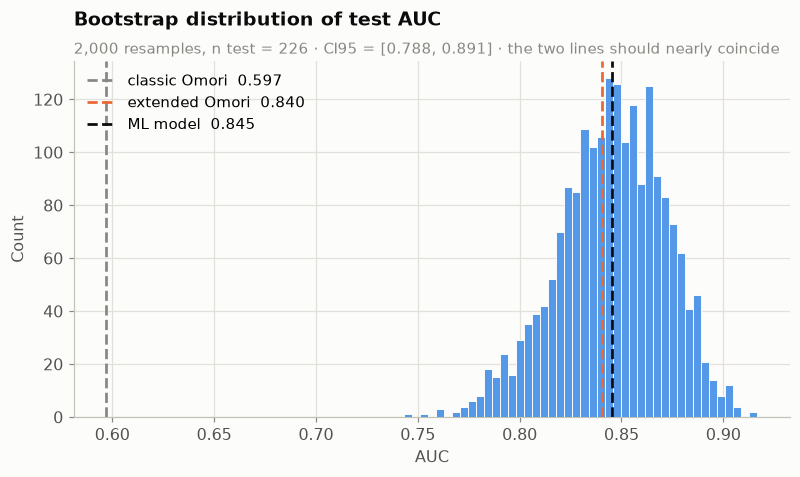

In [4]:
# 6b.1: bootstrap CI
auc_te, auc_tr, n_tr, n_te, p_te, y_te = base
rng = np.random.default_rng(0)
bs = []
for _ in range(2000):
    i = rng.integers(0, len(y_te), len(y_te))
    if len(np.unique(y_te[i])) < 2: continue
    bs.append(roc_auc_score(y_te[i], p_te[i]))
bs = np.array(bs)
lo, hi = np.percentile(bs, [2.5, 97.5])
om2 = rq2["omori_extended_auc"]; om1 = rq2["omori_auc"]

print(f"AUC                        = {auc_te:.4f}")
print(f"95% confidence interval    = [{lo:.4f}, {hi:.4f}]   (width {hi-lo:.4f})")
print(f"P(AUC <= classic Omori {om1:.3f})  = {(bs<=om1).mean()*100:.2f}%")
print(f"P(AUC <= extended Omori {om2:.3f}) = {(bs<=om2).mean()*100:.2f}%   <-- the number that matters")
print()
if (bs<=om2).mean() > 0.05:
    print("CONCLUSION: we CANNOT claim the ML model beats extended Omori.")
    print("            The two confidence intervals overlap.")
else:
    print("CONCLUSION: the ML model beats extended Omori with statistical significance.")

fig, ax = plt.subplots(figsize=(8.4,4.2))
ax.hist(bs, bins=44, color=SEQ5[1], edgecolor="white", linewidth=0.6, zorder=3)
for v,c,lab in [(om1,PAL["muted"],f"classic Omori  {om1:.3f}"),
                (om2,PAL["s2"],f"extended Omori  {om2:.3f}"),
                (auc_te,PAL["ink"],f"ML model  {auc_te:.3f}")]:
    ax.axvline(v, color=c, ls="--", lw=1.8, zorder=4, label=lab)
ax.legend(loc="upper left", fontsize=9.5)
finish(ax, "Bootstrap distribution of test AUC",
       f"2,000 resamples, n test = {n_te} · CI95 = [{lo:.3f}, {hi:.3f}] · the two lines should nearly coincide",
       "AUC", "Count")
save(fig, "fig_rq3_bootstrap_ci.png"); plt.show()

### 6b.2. Moving the label threshold to a **damaging** level: a check on practical relevance

The current label is "has an aftershock `M ≥ Mc`". But `Mc = 4.6` is a threshold **set by the catalog**, not one people care about. Nobody worries about an M4.6; people worry about events strong enough to cause damage.

This check moves the label to `M ≥ 5.0` and `M ≥ 5.5`, **what actually matters**, and sees whether the model still holds.

In [5]:
# 6b.2: move the label threshold to a damaging level
def count_after(sub, min_mag, hours=24, km=100):
    out = np.zeros(len(sub), dtype=np.int64)
    for k in range(len(sub)):
        r = sub.iloc[k]
        t0 = np.datetime64(r["time"].to_datetime64(), "s").astype(np.int64)
        a = np.searchsorted(t_s, t0); b = np.searchsorted(t_s, t0 + hours*3600)
        if b <= a: continue
        idx = np.arange(a,b)
        d = haversine_km(r["latitude"], r["longitude"], la_[idx], lo_[idx])
        out[k] = int(((d<=km)&(mg_[idx]<r["mag"])&(mg_[idx]>=min_mag)).sum())
    return out

rows=[]
for min_m, label in [(Mc,"CATALOG threshold (M>=Mc)"), (5.0,"mild DAMAGE threshold (M>=5.0)"),
                     (5.5,"clear DAMAGE threshold (M>=5.5)")]:
    d2 = ms.copy()
    d2["any_after"] = (count_after(d2, min_m) > 0).astype(int)
    r = eval_split(d2, FEATS, tr)
    if r is None:
        rows.append({"label_threshold":label,"threshold_M":min_m,"pct_positive":round(d2["any_after"].mean()*100,1),
                     "n_positive":int(d2["any_after"].sum()),"AUC_test":np.nan,"AUC_train":np.nan,
                     "gap":np.nan}); continue
    rows.append({"label_threshold":label,"threshold_M":min_m,
                 "pct_positive":round(d2["any_after"].mean()*100,1),
                 "n_positive":int(d2["any_after"].sum()),
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "gap":round(r[1]-r[0],4)})
thr = pd.DataFrame(rows)
thr.to_csv(REP/"table_rq3_label_threshold.csv", index=False)
display(thr)
print("HOW TO READ THIS TABLE: if the gap GROWS sharply at the damaging threshold,")
print("the clean result only exists at the threshold set by the DATA,")
print("not at the threshold people care about. That is a PRACTICAL LIMITATION")
print("that must go into the Discussion, not be skipped.")

,label_threshold,threshold_M,pct_positive,n_positive,AUC_test,AUC_train,gap
0,CATALOG threshold (M>=Mc),4.6,34.5,294,0.8454,0.8809,0.0355
1,mild DAMAGE threshold (M>=5.0),5.0,22.4,191,0.7653,0.8949,0.1297
2,clear DAMAGE threshold (M>=5.5),5.5,10.4,89,0.7794,0.9289,0.1496


HOW TO READ THIS TABLE: if the gap GROWS sharply at the damaging threshold,
the clean result only exists at the threshold set by the DATA,
not at the threshold people care about. That is a PRACTICAL LIMITATION
that must go into the Discussion, not be skipped.


### 6b.3. Changing the mainshock threshold

`M ≥ 5.5` was Notebook_A's choice. Check whether the conclusion changes with 5.0 or 6.0.

In [6]:
# 6b.3: change the mainshock threshold
indep = cat[~cat["is_aftershock"]].copy()
indep["year"] = pd.to_datetime(indep["time"], utc=True).dt.year
rows=[]
for th in [5.0, 5.5, 6.0]:
    sub = indep[indep["mag"] >= th].reset_index(drop=True).copy()
    sub["time"] = pd.to_datetime(sub["time"], utc=True)
    sub["any_after"] = (count_after(sub, Mc) > 0).astype(int)
    m_tr = (sub["year"] <= CUT).values
    r = eval_split(sub, FEATS, m_tr)
    if r is None: continue
    maj = max(sub["any_after"].mean(), 1-sub["any_after"].mean())
    rows.append({"mainshock_threshold":f"M>={th}","n_sequences":len(sub),
                 "pct_positive":round(sub["any_after"].mean()*100,1),
                 "naive_acc":round(maj,3),
                 "n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"gap":round(r[1]-r[0],4)})
thr2 = pd.DataFrame(rows)
thr2.to_csv(REP/"table_rq3_mainshock_threshold.csv", index=False)
display(thr2)
print("The conclusion is robust if AUC_test at all three thresholds is clearly above 0.5.")

,mainshock_threshold,n_sequences,pct_positive,naive_acc,n_train,n_test,AUC_test,gap
0,M>=5.0,2285,22.1,0.779,1612,673,0.7830,0.0844
1,M>=5.5,853,34.5,0.655,627,226,0.8454,0.0355
2,M>=6.0,322,49.7,0.503,249,73,0.8563,0.0633


The conclusion is robust if AUC_test at all three thresholds is clearly above 0.5.


### 6b.4. Dropping 2011 entirely: is Tohoku carrying the whole signal?

Notebook_A showed that 2011 holds a very large share of all events. If dropping that year makes the result collapse, the work really only describes **one earthquake**, not a general pattern.

In [7]:
# 6b.4: drop 2011
rows=[]
for label, keep in [("as is (with 2011)", np.ones(len(ms), bool)),
                    ("DROP 2011 entirely", (ms["year"] != 2011).values),
                    ("drop 2011-2012", (~ms["year"].isin([2011,2012])).values)]:
    d3 = ms[keep].reset_index(drop=True)
    m_tr = (d3["year"] <= CUT).values
    r = eval_split(d3, FEATS, m_tr)
    if r is None: continue
    rows.append({"scenario":label,"n_sequences":len(d3),
                 "pct_positive":round(d3["any_after"].mean()*100,1),
                 "n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "gap":round(r[1]-r[0],4)})
toh = pd.DataFrame(rows)
toh.to_csv(REP/"table_rq3_tohoku.csv", index=False)
display(toh)
delta = toh.loc[0,"AUC_test"] - toh.loc[1,"AUC_test"]
print(f"\nAUC drops by {delta:+.4f} when 2011 is removed.")
print("Drop below 0.05 -> the conclusion does NOT depend on Tohoku." if abs(delta)<0.05
      else "Drop above 0.05 -> the work must state that it depends on Tohoku.")

,scenario,n_sequences,pct_positive,n_train,n_test,AUC_test,AUC_train,gap
0,as is (with 2011),853,34.5,627,226,0.8454,0.8809,0.0355
1,DROP 2011 entirely,798,31.7,572,226,0.8444,0.8857,0.0413
2,drop 2011-2012,788,31.9,562,226,0.8489,0.8884,0.0395



AUC drops by +0.0010 when 2011 is removed.
Drop below 0.05 -> the conclusion does NOT depend on Tohoku.


### 6b.5. Splitting by **geographic region** instead of time

A time split tests generalization to the *future*. A region split tests generalization to *places not seen*: harder, and the closest check to "leave-one-group-out".

Regions by latitude: south (24-34°N), middle (34-40°N), north (40-46°N). Train on two regions, test on the remaining one.

In [8]:
# 6b.5: leave-one-region-out
ms2 = ms.copy()
ms2["region"] = pd.cut(ms2["latitude"], [24,34,40,46],
                       labels=["south (24-34N)","middle (34-40N)","north (40-46N)"])
print(ms2.groupby("region", observed=True).agg(
    n_sequences=("any_after","size"), pct_positive=("any_after","mean")).assign(
    pct_positive=lambda d: (d["pct_positive"]*100).round(1)).to_string())

rows=[]
for v in ms2["region"].cat.categories:
    m_tr = (ms2["region"] != v).values
    r = eval_split(ms2, FEATS, m_tr)
    if r is None:
        rows.append({"held_out_region":v,"n_train":int(m_tr.sum()),"n_test":int((~m_tr).sum()),
                     "AUC_test":np.nan,"note":"this region has only one class"}); continue
    rows.append({"held_out_region":v,"n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "gap":round(r[1]-r[0],4),"note":""})
reg = pd.DataFrame(rows)
reg.to_csv(REP/"table_rq3_region.csv", index=False)
display(reg)
print(f"Mean AUC with a region split : {reg['AUC_test'].mean():.4f}")
print(f"AUC with a time split        : {auc_te:.4f}")
print("If the region split is much lower -> the model depends on region-specific traits.")

                 n_sequences  pct_positive
region                                    
south (24-34N)           395          32.7
middle (34-40N)          237          45.1
north (40-46N)           221          26.2


,held_out_region,n_train,n_test,AUC_test,AUC_train,gap,note
0,south (24-34N),458,395,0.7924,0.9132,0.1208,
1,middle (34-40N),616,237,0.8135,0.8872,0.0737,
2,north (40-46N),632,221,0.8565,0.8730,0.0165,


Mean AUC with a region split : 0.8208
AUC with a time split        : 0.8454
If the region split is much lower -> the model depends on region-specific traits.


### 6b.6. Changing the declustering parameters

Gardner-Knopoff is a choice, not a truth. Multiply the space-time window by 0.5 and 2.0, decluster again from scratch, and see how much the number of sequences and the conclusion change.

In [9]:
# 6b.6: sensitivity to the declustering method
def decluster(scale_d=1.0, scale_t=1.0):
    n = len(cat); cl = np.full(n,-1,np.int64); cid=0
    for i in np.argsort(-mg_):
        if cl[i] != -1: continue
        d_km = 10**(0.1238*mg_[i]+0.983) * scale_d
        t_day = (10**(0.032*mg_[i]+2.7389) if mg_[i]>=6.5 else 10**(0.5409*mg_[i]-0.547)) * scale_t
        a = np.searchsorted(t_s, t_s[i]); b = np.searchsorted(t_s, t_s[i]+int(t_day*86400))
        if b <= a+1: continue
        idx = np.arange(a,b); idx = idx[(cl[idx]==-1)&(mg_[idx]<mg_[i])&(idx!=i)]
        if idx.size==0: continue
        hit = idx[haversine_km(la_[i],lo_[i],la_[idx],lo_[idx]) <= d_km]
        if hit.size: cl[hit]=cid; cid+=1
    return cl

rows=[]
for nm, sd_, st_ in [("window x0.5 (tight)",0.5,0.5), ("original Gardner-Knopoff",1.0,1.0),
                     ("window x2.0 (wide)",2.0,2.0)]:
    cl = decluster(sd_, st_)
    ind = cat[cl==-1].copy()
    ind["time"] = pd.to_datetime(ind["time"], utc=True)
    ind["year"] = ind["time"].dt.year
    sub = ind[ind["mag"] >= man["mainshock_min_mag"]].reset_index(drop=True)
    sub["any_after"] = (count_after(sub, Mc) > 0).astype(int)
    m_tr = (sub["year"] <= CUT).values
    r = eval_split(sub, FEATS, m_tr)
    rows.append({"method":nm,"pct_aftershocks":round((cl!=-1).mean()*100,1),
                 "n_sequences":len(sub),"pct_positive":round(sub["any_after"].mean()*100,1),
                 "AUC_test":round(r[0],4) if r else np.nan,
                 "gap":round(r[1]-r[0],4) if r else np.nan})
dec = pd.DataFrame(rows)
dec.to_csv(REP/"table_rq3_declustering.csv", index=False)
display(dec)
print(f"AUC range across the three methods: {dec['AUC_test'].max()-dec['AUC_test'].min():.4f}")
print("Below 0.05 -> the conclusion does not depend on the declustering choice.")

,method,pct_aftershocks,n_sequences,pct_positive,AUC_test,gap
0,window x0.5 (tight),43.6,1112,39.0,0.8366,0.0234
1,original Gardner-Knopoff,62.3,853,34.5,0.8454,0.0355
2,window x2.0 (wide),84.4,485,33.8,0.8253,0.0830


AUC range across the three methods: 0.0201
Below 0.05 -> the conclusion does not depend on the declustering choice.


### 6b.7. Dropping events with a **default** depth (10 / 33 / 35 km)

When the depth cannot be determined, USGS often assigns a fixed value (10, 33 or 35 km) instead of a measured depth. Depth is the model's most important variable, so this has to be checked: if dropping these events clearly weakens the depth signal, the RQ1/RQ2 conclusions partly rest on filled-in values.

In [10]:
# 6b.7: drop events with a default depth
FIXED_DEPTHS = [10.0, 33.0, 35.0]
is_fixed = ms["depth"].isin(FIXED_DEPTHS).values
print(f"Mainshocks with a default depth: {is_fixed.sum()} / {len(ms)} ({is_fixed.mean()*100:.1f}%)")
print(f"  share with aftershock: default depth {ms.loc[is_fixed,'any_after'].mean()*100:.1f}%"
      f" | measured depth (<70 km) {ms.loc[~is_fixed & (ms['depth']<70),'any_after'].mean()*100:.1f}%")

def omori_depth_auc(df, m_tr):
    "Extended Omori (magnitude + depth) as in Notebook_B, re-evaluated on a subset."
    X = np.column_stack([df["mag"]-Mc, df["depth"]/100.0])
    p = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(X[m_tr], df.loc[m_tr,"n_after24h"])
    return roc_auc_score(df.loc[~m_tr,"any_after"], 1-np.exp(-p.predict(X[~m_tr])))

rows=[]
for label, keep in [("as is", np.ones(len(ms), bool)),
                    ("DROP default depths", ~is_fixed)]:
    d4 = ms[keep].reset_index(drop=True)
    m_tr = (d4["year"] <= CUT).values
    r = eval_split(d4, FEATS, m_tr)
    rows.append({"scenario":label,"n_sequences":len(d4),
                 "pct_positive":round(d4["any_after"].mean()*100,1),
                 "n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "gap":round(r[1]-r[0],4),
                 "AUC_omori_extended":round(omori_depth_auc(d4, m_tr),4),
                 "spearman_depth":round(stats.spearmanr(d4["depth"], d4["n_after24h"])[0],3)})
fdp = pd.DataFrame(rows)
fdp.to_csv(REP/"table_rq3_fixed_depth.csv", index=False)
display(fdp)
delta_fd = fdp.loc[1,"AUC_test"] - fdp.loc[0,"AUC_test"]
print(f"\nAUC changes by {delta_fd:+.4f} when default depths are dropped; "
      f"depth Spearman {fdp.loc[0,'spearman_depth']:+.3f} -> {fdp.loc[1,'spearman_depth']:+.3f}")
print("Change below 0.05 -> the depth signal is NOT an artifact of filled-in values." if abs(delta_fd)<0.05
      else "Change above 0.05 -> the work must state that it depends on default depths.")

Mainshocks with a default depth: 158 / 853 (18.5%)
  share with aftershock: default depth 53.2% | measured depth (<70 km) 42.0%


,scenario,n_sequences,pct_positive,n_train,n_test,AUC_test,AUC_train,gap,AUC_omori_extended,spearman_depth
0,as is,853,34.5,627,226,0.8454,0.8809,0.0355,0.8402,-0.492
1,DROP default depths,695,30.2,501,194,0.8544,0.9090,0.0546,0.8473,-0.506



AUC changes by +0.0090 when default depths are dropped; depth Spearman -0.492 -> -0.506
Change below 0.05 -> the depth signal is NOT an artifact of filled-in values.


## Step 6c: explaining the model: what does it actually use?

Permutation importance: shuffle each column and measure how much AUC drops. If shuffling a column leaves AUC unchanged, the model **does not use** that column.

,feature,auc_drop,sd
0,mag,0.0644,0.0179
1,depth,0.3014,0.0307


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq3_importance_and_depth.png


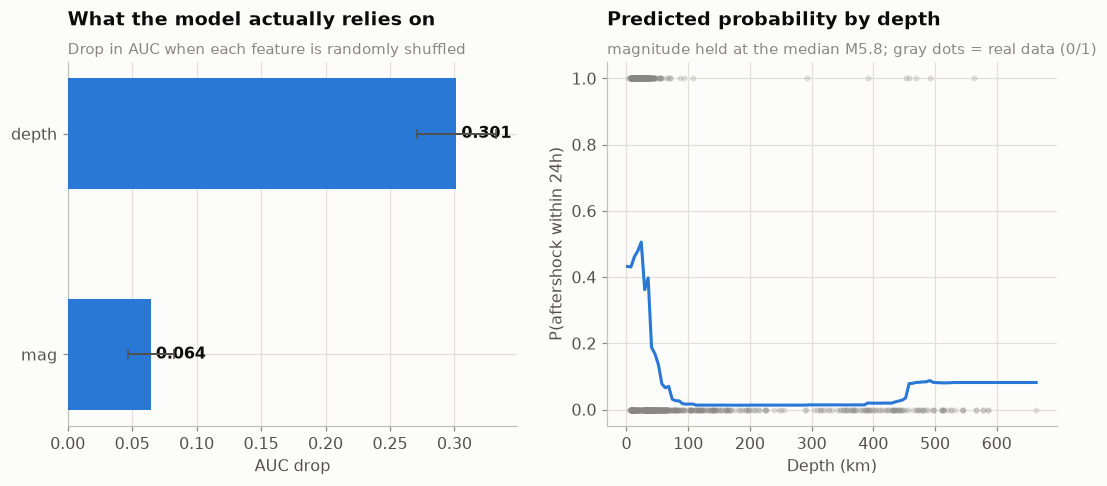

In [11]:
# 6c: permutation importance + partial dependence curve
from sklearn.inspection import permutation_importance

mdl = make_model().fit(ms.loc[tr, FEATS], ms.loc[tr,"any_after"])
pi = permutation_importance(mdl, ms.loc[~tr, FEATS], ms.loc[~tr,"any_after"],
                            scoring="roc_auc", n_repeats=30, random_state=0, n_jobs=1)
imp = pd.DataFrame({"feature":FEATS,"auc_drop":pi.importances_mean.round(4),
                    "sd":pi.importances_std.round(4)}).sort_values("auc_drop")
imp.to_csv(REP/"table_rq3_importance.csv", index=False)
display(imp)

fig, axes = plt.subplots(1,2, figsize=(11.6,4.3))
ax = axes[0]
bars = ax.barh(imp["feature"], imp["auc_drop"], xerr=imp["sd"],
               color=PAL["s1"], height=0.5, zorder=3,
               error_kw=dict(ecolor=PAL["ink2"], elinewidth=1.3, capsize=3))
for i,v in enumerate(imp["auc_drop"]):
    ax.text(v+0.004, i, f"{v:.3f}", va="center", fontsize=10.5,
            color=PAL["ink"], fontweight="semibold")
finish(ax, "What the model actually relies on",
       "Drop in AUC when each feature is randomly shuffled", "AUC drop", None)

ax = axes[1]
grid = np.linspace(ms["depth"].min(), min(ms["depth"].max(), 700), 120)
med_mag = ms["mag"].median()
probe = pd.DataFrame({"mag":med_mag, "depth":grid})[FEATS]
ax.plot(grid, mdl.predict_proba(probe)[:,1], color=PAL["s1"], zorder=4)
ax.scatter(ms["depth"], ms["any_after"], s=9, alpha=0.18, color=PAL["muted"], zorder=3)
finish(ax, "Predicted probability by depth",
       f"magnitude held at the median M{med_mag:.1f}; gray dots = real data (0/1)",
       "Depth (km)", "P(aftershock within 24h)")
save(fig, "fig_rq3_importance_and_depth.png"); plt.show()

## Diagnosis and next steps (the Discussion part, written by Student C)

The cell below collects every check into one table, with an **automatic verdict** based on thresholds set in advance.

In [12]:
# Summary diagnosis table
def verdict(cond, ok="ROBUST", bad="WEAK"): return ok if cond else bad

diag = [
 {"check":"1. Bootstrap confidence interval",
  "result":f"AUC {auc_te:.3f}, CI95 [{lo:.3f}, {hi:.3f}]",
  "verdict":verdict(lo > 0.70, "ROBUST (CI lower bound > 0.70)", "WEAK (CI reaches a low level)")},
 {"check":"2. Label moved to a damaging level",
  "result":f"gap {thr.loc[0,'gap']:.3f} -> {thr['gap'].max():.3f}",
  "verdict":verdict(thr["gap"].max() < 0.12,
                    "ROBUST", "WEAK - the clean result only exists at the catalog threshold")},
 {"check":"3. Mainshock threshold changed",
  "result":f"AUC {thr2['AUC_test'].min():.3f} - {thr2['AUC_test'].max():.3f}",
  "verdict":verdict(thr2["AUC_test"].min() > 0.70)},
 {"check":"4. 2011 dropped (Tohoku)",
  "result":f"AUC changes {delta:+.3f}",
  "verdict":verdict(abs(delta) < 0.05, "ROBUST - does not depend on Tohoku",
                    "WEAK - depends on Tohoku")},
 {"check":"5. Split by geographic region",
  "result":f"mean AUC {reg['AUC_test'].mean():.3f} (vs {auc_te:.3f} with a time split)",
  "verdict":verdict(reg["AUC_test"].mean() > 0.70)},
 {"check":"6. Declustering parameters changed",
  "result":f"AUC range {dec['AUC_test'].max()-dec['AUC_test'].min():.3f}",
  "verdict":verdict(dec["AUC_test"].max()-dec["AUC_test"].min() < 0.05)},
 {"check":"7. Default depths dropped (10/33/35 km)",
  "result":f"AUC changes {delta_fd:+.3f} ({fdp.loc[1,'n_sequences']} sequences)",
  "verdict":verdict(abs(delta_fd) < 0.05, "ROBUST - does not depend on default depths",
                    "WEAK - depends on default depths")},
 {"check":"8. Does ML beat the 2-variable physics model",
  "result":f"ML {rq2['auc_test']:.3f} vs extended Omori {rq2['omori_extended_auc']:.3f} "
           f"({rq2['gain_from_model_type']:+.3f})",
  "verdict":verdict(rq2["gain_from_model_type"] > 0.03,
                    "ML has its own contribution", "ML adds NOTHING significant beyond feature choice")},
]
diag = pd.DataFrame(diag)
diag.to_csv(REP/"table_rq3_diagnosis.csv", index=False)
display(diag)
n_robust = diag["verdict"].str.startswith("ROBUST").sum() + (diag["verdict"]=="ROBUST").sum()
print(f"\nChecks passed (ROBUST): {diag['verdict'].str.contains('ROBUST|own contribution').sum()}/{len(diag)}")

,check,result,verdict
0,1. Bootstrap confidence interval,"AUC 0.845, CI95 [0.788, 0.891]",ROBUST (CI lower bound > 0.70)
1,2. Label moved to a damaging level,gap 0.035 -> 0.150,WEAK - the clean result only exists at the cat...
2,3. Mainshock threshold changed,AUC 0.783 - 0.856,ROBUST
3,4. 2011 dropped (Tohoku),AUC changes +0.001,ROBUST - does not depend on Tohoku
4,5. Split by geographic region,mean AUC 0.821 (vs 0.845 with a time split),ROBUST
5,6. Declustering parameters changed,AUC range 0.020,ROBUST
6,7. Default depths dropped (10/33/35 km),AUC changes +0.009 (695 sequences),ROBUST - does not depend on default depths
7,8. Does ML beat the 2-variable physics model,ML 0.846 vs extended Omori 0.840 (+0.005),ML adds NOTHING significant beyond feature choice



Checks passed (ROBUST): 6/8


### Three limitations that must go into the Discussion, not be hidden

1. **USGS is not Japan's primary seismic agency.** The primary agency is JMA, whose catalog is complete down to about M2-3, while the global USGS catalog is only complete from `Mc ≈ 4.6`. This means the model **does not see most real aftershocks**, and an operational system in Japan would not use it. The contribution of this work is **a tested method on a U.S. federal data source**, not a tool usable for Japan.

2. **The study region includes Russia's Kuril Islands**, so it must be called the "Japan-Kuril region". Geologically it is continuous (one subduction zone), so it is not scientifically wrong, but the naming would be.

3. **Most of the improvement comes from choosing the right variable, not from machine learning** (Notebook_B measured this: see `gain_from_depth` vs `gain_from_model_type`). The honest conclusion is: this work finds **a pattern in the data**, and uses ML to confirm it.

### Next steps given more time

- Compare against **ETAS** (Epidemic-Type Aftershock Sequence), the model actually used in operations, not only against Omori-Utsu.
- Add **faulting mechanism** (moment tensor): this variable is what really drives aftershock productivity, and the basic catalog does not have it.
- Forecast the **number** of aftershocks with Poisson/Negative-Binomial regression instead of just yes/no.

## Notebook_C test cases

In [13]:
# Notebook_C test cases
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Notebook_C test cases")
t("1. reproduces Notebook_B's result", abs(base[0]-rq2["auc_test"]) < 0.02,
  f"difference {abs(base[0]-rq2['auc_test']):.4f}")
t("2. all 7 robustness checks ran",
  all(len(x)>0 for x in [thr, thr2, toh, reg, dec, fdp]) and len(bs)>1000)
t("3. the confidence interval excludes 0.5", lo > 0.5, f"lower bound = {lo:.4f}")
t("4. the conclusion does not depend on a single year", abs(delta) < 0.15, f"change {delta:+.4f}")
t("5. the conclusion does not depend on the declustering method",
  dec["AUC_test"].max()-dec["AUC_test"].min() < 0.15)
t("6. the conclusion does not depend on default depths", abs(delta_fd) < 0.15, f"change {delta_fd:+.4f}")
t("7. diagnosis table saved", (REP/"table_rq3_diagnosis.csv").exists())

rq3 = {"auc":float(auc_te), "ci95":[float(lo), float(hi)],
       "p_below_omori_extended": float((bs<=om2).mean()),
       "delta_drop_2011": float(delta),
       "auc_region_split": float(reg["AUC_test"].mean()),
       "declustering_auc_range": float(dec["AUC_test"].max()-dec["AUC_test"].min()),
       "gap_damaging_threshold": float(thr["gap"].max()),
       "delta_drop_fixed_depth": float(delta_fd)}
json.dump(rq3, open(PROC/"rq3_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
print("\n" + json.dumps(rq3, ensure_ascii=False, indent=2))

Notebook_C test cases
  PASS  1. reproduces Notebook_B's result
  PASS  2. all 7 robustness checks ran
  PASS  3. the confidence interval excludes 0.5
  PASS  4. the conclusion does not depend on a single year
  PASS  5. the conclusion does not depend on the declustering method
  PASS  6. the conclusion does not depend on default depths
  PASS  7. diagnosis table saved

{
  "auc": 0.8453650872405524,
  "ci95": [
    0.7880503987630414,
    0.8911625141636271
  ],
  "p_below_omori_extended": 0.4,
  "delta_drop_2011": 0.0010000000000000009,
  "auc_region_split": 0.8208000000000001,
  "declustering_auc_range": 0.020100000000000007,
  "gap_damaging_threshold": 0.1496,
  "delta_drop_fixed_depth": 0.009000000000000008
}


## Common errors and fixes (read when you see red text)

| Red text | Cause | Fix |
|---|---|---|
| `eval_split` returns `None` | the region or threshold has only one class left | normal for small regions; the table records it in `note`, no fix needed |
| `ValueError: Only one class present` | a bootstrap sample drew only one class | already skipped with `if len(np.unique(...)) < 2: continue` |
| Cell 6b.6 runs very long | declusters 3 times over 16k events | 1-3 minutes is normal; do not interrupt it |
| `KeyError: 'omori_extended_auc'` | an old version of Notebook_B was run | re-run all of Notebook_B |
| Region-split AUC is much lower | the model really does depend on region | **not a bug**: record it in the Discussion |

## Checklist before reporting (tick [x] when the evidence file exists)

- [ ] `report/table_rq3_label_threshold.csv`: gap at the damaging threshold
- [ ] `report/table_rq3_mainshock_threshold.csv`
- [ ] `report/table_rq3_tohoku.csv`: results with 2011 dropped
- [ ] `report/table_rq3_region.csv`: region split
- [ ] `report/table_rq3_declustering.csv`: declustering sensitivity
- [ ] `report/table_rq3_fixed_depth.csv`: results with default depths dropped
- [ ] `report/table_rq3_importance.csv`
- [ ] `report/table_rq3_diagnosis.csv`: **the summary table, goes straight onto a slide**
- [ ] `fig_rq3_bootstrap_ci.png`, `fig_rq3_importance_and_depth.png`
- [ ] All 7 test cases PASS
- [ ] The Discussion **covers all three limitations** above
- [ ] Every check with a "WEAK" result **is stated in the report**, not hidden
- [ ] `docs/AI_Audit_Log_C.md` complete

## Progress report template (slot 3, Tuesdays and Fridays, 7:00 to 9:15)

**Student C: Notebook_C, week …**

1. **Done:** 7 robustness checks + permutation importance.
2. **Key numbers:** AUC = …, CI95 = [… , …]; dropping 2011 changes AUC by …; dropping default depths changes AUC by …; region split …; declustering range ….
3. **Checks with weak results:** … (state them clearly, do not hide them).
4. **Limitations written into the Discussion:** USGS ≠ JMA; the region includes the Kurils; the gain comes mainly from variable choice, not from ML.
5. **Blockers:** …
6. **Next week:** finish Results and Discussion together with D.